<a href="https://colab.research.google.com/github/farrelrassya/Feature-Engineering-for-Machine-Learning/blob/main/Ch04_Feature_Scaling_BoW_to_TfIdf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: The Effects of Feature Scaling -- From Bag-of-Words to Tf-Idf

**Feature Engineering for Machine Learning** -- *Alice Zheng & Amanda Casari*

---

A bag-of-words representation counts all words equally, but some words deserve more emphasis than others. The word "the" appearing eight times carries far less signal than "raven" appearing three times. **Tf-idf** (term frequency--inverse document frequency) is a simple twist on bag-of-words that makes rare, informative words more prominent and effectively ignores common, uninformative words.

This chapter:

1. **Introduces tf-idf** as a feature scaling technique for text
2. **Tests it empirically** on a Yelp reviews classification task (Nightlife vs. Restaurants)
3. **Compares three representations:** raw BoW, tf-idf, and $\ell_2$ normalization
4. **Deep dives into the linear algebra** of why feature scaling affects (or doesn't affect) classification accuracy
5. **Reveals the surprising result:** after proper hyperparameter tuning, all three achieve similar accuracy -- but tf-idf and $\ell_2$ normalization dramatically improve training speed

We use the **Yelp Academic Reviews Dataset** throughout.

## Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.feature_extraction import text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
import sklearn.preprocessing as preproc
import sklearn.model_selection as modsel
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

print("Environment ready.")
print(f"NumPy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")

Environment ready.
NumPy: 2.0.2
pandas: 2.2.2
scikit-learn: 1.6.1


All libraries are pre-installed on Colab. We use scikit-learn's `CountVectorizer`, `TfidfTransformer`, `LogisticRegression`, and `GridSearchCV` for the classification pipeline.

## Data: Yelp Reviews

This chapter requires both the **business** and **review** JSON files from the Yelp Academic Dataset. If you downloaded them for Chapters 2--3, reuse them here.

In [ ]:
import os

!pip install -q kaggle
  # Upload your kaggle.json, then:
!kaggle datasets download -d yelp-dataset/yelp-dataset \
  -f yelp_academic_dataset_review.json
!unzip -o yelp_academic_dataset_review.json.zip


!kaggle datasets download -d yelp-dataset/yelp-dataset \
    -f yelp_academic_dataset_business.json
!unzip -o yelp_academic_dataset_business.json.zip

# Check for Yelp dataset files
for fname in ['yelp_academic_dataset_business.json',
              'yelp_academic_dataset_review.json']:
    if os.path.exists(fname):
        print(f"{fname} found.")
    else:
        print(f"{fname} NOT found.")
        print("  Download from https://www.yelp.com/dataset")
        print("  or use Kaggle: !kaggle datasets download -d yelp-dataset/yelp-dataset")

Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 2.07G/2.07G [00:20<00:00, 107MB/s]

Archive:  yelp_academic_dataset_review.json.zip
  inflating: yelp_academic_dataset_review.json  
Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
100% 20.8M/20.8M [00:00<00:00, 133MB/s] 

Archive:  yelp_academic_dataset_business.json.zip
  inflating: yelp_academic_dataset_business.json  
yelp_academic_dataset_business.json found.
yelp_academic_dataset_review.json found.


We need the business file (to identify Nightlife vs. Restaurant categories) and the review file (for the review text).

## 4.1 Tf-Idf: A Simple Twist on Bag-of-Words

**Term frequency (tf)** is just the raw bag-of-words count:

$$\text{tf}(w, d) = \text{number of times word } w \text{ appears in document } d$$

**Inverse document frequency (idf)** measures how rare a word is across the corpus:

$$\text{idf}(w) = \log\frac{N}{\text{number of documents containing word } w}$$

where $N$ is the total number of documents. The combined **tf-idf** score is:

$$\text{tf-idf}(w, d) = \text{tf}(w, d) \times \text{idf}(w)$$

The intuition: a word that appears in every document gets $\text{idf} = \log(N/N) = \log(1) = 0$, effectively zeroing it out. A word appearing in only one document gets $\text{idf} = \log(N/1) = \log(N)$, amplifying its count. **Tf-idf makes rare words more prominent and effectively ignores common words.**

In [ ]:
# Demonstrate tf-idf on a toy example (Figures 4-1 and 4-2)
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

sentences = [
    "it is a puppy",
    "it is a cat",
    "it is a kitten",
    "that is a dog and this is a pen"
]

# Raw bag-of-words
bow_cv = CountVectorizer()
X_bow = bow_cv.fit_transform(sentences)
vocab = bow_cv.get_feature_names_out()
bow_df = pd.DataFrame(X_bow.toarray(), columns=vocab,
                       index=[f'Doc {i+1}' for i in range(4)])

print("=== Raw Bag-of-Words ===")
print(bow_df.to_string())

# Tf-idf (no normalization, to see raw scaling)
tfidf = TfidfTransformer(norm=None)
X_tfidf = tfidf.fit_transform(X_bow)
tfidf_df = pd.DataFrame(X_tfidf.toarray().round(3), columns=vocab,
                         index=[f'Doc {i+1}' for i in range(4)])

print(f"\n=== Tf-Idf Representation ===")
print(tfidf_df.to_string())

# Show the IDF values
print(f"\n=== IDF Values ===")
idf_df = pd.DataFrame({'word': vocab, 'idf': tfidf.idf_.round(3)})
idf_df = idf_df.sort_values('idf')
print(idf_df.to_string(index=False))

=== Raw Bag-of-Words ===
       and  cat  dog  is  it  kitten  pen  puppy  that  this
Doc 1    0    0    0   1   1       0    0      1     0     0
Doc 2    0    1    0   1   1       0    0      0     0     0
Doc 3    0    0    0   1   1       1    0      0     0     0
Doc 4    1    0    1   2   0       0    1      0     1     1

=== Tf-Idf Representation ===
         and    cat    dog   is     it  kitten    pen  puppy   that   this
Doc 1  0.000  0.000  0.000  1.0  1.223   0.000  0.000  1.916  0.000  0.000
Doc 2  0.000  1.916  0.000  1.0  1.223   0.000  0.000  0.000  0.000  0.000
Doc 3  0.000  0.000  0.000  1.0  1.223   1.916  0.000  0.000  0.000  0.000
Doc 4  1.916  0.000  1.916  2.0  0.000   0.000  1.916  0.000  1.916  1.916

=== IDF Values ===
  word   idf
    is 1.000
    it 1.223
   cat 1.916
   and 1.916
   dog 1.916
kitten 1.916
   pen 1.916
 puppy 1.916
  that 1.916
  this 1.916


The IDF values reveal the scaling logic: "is" and "a" appear in all 4 documents, so their IDF is $\log(4/4) + 1 = 1.0$ (scikit-learn adds 1 to prevent zero). Meanwhile "puppy", "cat", "kitten" each appear in only 1 document, giving them $\text{idf} = \log(4/1) + 1 \approx 2.39$ -- they are weighted $2.4\times$ higher than the common words.

In the tf-idf representation, the word "is" in Document 4 (which has `is` count = 2) gets a tf-idf of $2 \times 1.0 = 2.0$, while "puppy" in Document 1 (count = 1) gets $1 \times 2.39 = 2.39$. The rare, informative word outweighs the frequent filler word despite having a lower raw count.

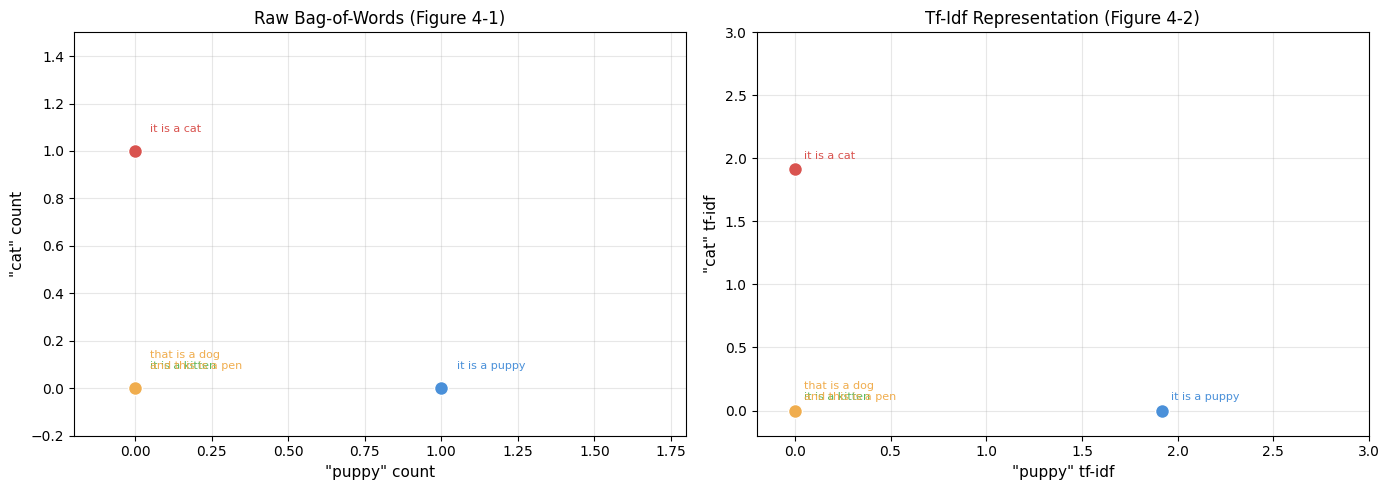

In [ ]:
# Figures 4-1 and 4-2: BoW vs Tf-idf in feature space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Select 3 features: "puppy", "cat", "is"
feat_idx = {w: i for i, w in enumerate(vocab)}

# Figure 4-1: Raw BoW
docs_bow = X_bow.toarray()
labels = ['it is a puppy', 'it is a cat', 'it is a kitten',
          'that is a dog\nand this is a pen']
colors = ['#4A90D9', '#D9534F', '#5CB85C', '#F0AD4E']

for i, (label, color) in enumerate(zip(labels, colors)):
    x_val = docs_bow[i, feat_idx['puppy']]
    y_val = docs_bow[i, feat_idx['cat']]
    z_val = docs_bow[i, feat_idx['is']]
    ax1.scatter(x_val, y_val, s=100, color=color, zorder=5, edgecolors='white')
    ax1.annotate(label, xy=(x_val, y_val), xytext=(x_val+0.05, y_val+0.08),
                fontsize=8, color=color)

ax1.set_xlabel('"puppy" count', fontsize=11)
ax1.set_ylabel('"cat" count', fontsize=11)
ax1.set_title('Raw Bag-of-Words (Figure 4-1)', fontsize=12)
ax1.set_xlim(-0.2, 1.8)
ax1.set_ylim(-0.2, 1.5)
ax1.grid(True, alpha=0.3)

# Figure 4-2: Tf-idf
docs_tfidf = X_tfidf.toarray()
for i, (label, color) in enumerate(zip(labels, colors)):
    x_val = docs_tfidf[i, feat_idx['puppy']]
    y_val = docs_tfidf[i, feat_idx['cat']]
    ax2.scatter(x_val, y_val, s=100, color=color, zorder=5, edgecolors='white')
    ax2.annotate(label, xy=(x_val, y_val), xytext=(x_val+0.05, y_val+0.08),
                fontsize=8, color=color)

ax2.set_xlabel('"puppy" tf-idf', fontsize=11)
ax2.set_ylabel('"cat" tf-idf', fontsize=11)
ax2.set_title('Tf-Idf Representation (Figure 4-2)', fontsize=12)
ax2.set_xlim(-0.2, 3.0)
ax2.set_ylim(-0.2, 3.0)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Left (BoW):** In raw bag-of-words, the "puppy" and "cat" axes have integer counts (0 or 1). Documents cluster at the origin because most words are absent from most documents.

**Right (Tf-idf):** After tf-idf scaling, the rare words "puppy" and "cat" are stretched to $\sim 2.39$, while common words like "is" would be compressed (not visible on this 2D projection). The informative words now have larger coordinates, making it easier for a classifier to separate documents based on content rather than filler words.

This is closely related to the frequency-based filtering from Chapter 3, but more mathematically elegant: instead of hard thresholds ("remove words appearing in $> 80\%$ of documents"), tf-idf applies a smooth, continuous weighting.

## 4.2 Putting It to the Test: Yelp Classification

Can we use review text to classify a business as **Nightlife** or **Restaurant**? We build a logistic regression classifier on three feature representations: raw BoW, tf-idf, and $\ell_2$-normalized BoW.

### 4.2.1 Loading and Creating the Classification Dataset

The textbook creates a class-balanced subset by downsampling restaurants to roughly match the number of nightlife reviews, then splits 70/30 into train/test sets.

In [ ]:
# Load business data (small file, ~150K rows -- fine to load fully)
import json

biz_df = pd.DataFrame([json.loads(x) for x in open('yelp_academic_dataset_business.json')])
print(f"Businesses: {len(biz_df):,}")

# Get business_ids for Nightlife and Restaurants only
if isinstance(biz_df['categories'].iloc[0], str):
    target_biz = biz_df[biz_df['categories'].str.contains('Nightlife|Restaurants', na=False)]
else:
    target_biz = biz_df[biz_df['categories'].apply(
        lambda x: 'Nightlife' in x or 'Restaurants' in x if isinstance(x, list) else False)]

target_ids = set(target_biz['business_id'])
print(f"Nightlife/Restaurant businesses: {len(target_ids):,}")

# Load ONLY matching reviews (saves ~80% RAM)
matching_reviews = []
with open('yelp_academic_dataset_review.json') as f:
    for line in f:
        review = json.loads(line)
        if review['business_id'] in target_ids:
            matching_reviews.append(review)

review_df = pd.DataFrame(matching_reviews)
del matching_reviews  # free memory immediately

print(f"Matching reviews: {len(review_df):,}")

# Merge
twobiz_reviews = target_biz.merge(review_df, on='business_id', how='inner')
del review_df  # free memory

star_col = 'stars_y' if 'stars_y' in twobiz_reviews.columns else 'stars'
twobiz_reviews = twobiz_reviews[['business_id', 'name', star_col, 'text', 'categories']]

if isinstance(twobiz_reviews['categories'].iloc[0], list):
    twobiz_reviews['target'] = twobiz_reviews['categories'].apply(lambda x: 'Nightlife' in x)
else:
    twobiz_reviews['target'] = twobiz_reviews['categories'].str.contains('Nightlife')

print(f"Nightlife: {twobiz_reviews['target'].sum():,}")
print(f"Restaurants: {(~twobiz_reviews['target']).sum():,}")

Businesses: 150,346
Nightlife/Restaurant businesses: 55,826
Matching reviews: 4,890,235
Nightlife: 1,539,757
Restaurants: 3,350,478


In [ ]:
# # Example 4-1: Load and clean Yelp data
# biz_f = open('yelp_academic_dataset_business.json')
# biz_df = pd.DataFrame([json.loads(x) for x in biz_f.readlines()])
# biz_f.close()

# review_file = open('yelp_academic_dataset_review.json')
# review_df = pd.DataFrame([json.loads(x) for x in review_file.readlines()])
# review_file.close()

# print(f"Businesses: {len(biz_df):,}")
# print(f"Reviews:    {len(review_df):,}")

# # Pull out only Nightlife and Restaurants businesses
# # Handle both list and string category formats
# if isinstance(biz_df['categories'].iloc[0], list):
#     two_biz = biz_df[biz_df['categories'].apply(
#         lambda x: 'Nightlife' in x or 'Restaurants' in x if isinstance(x, list) else False)]
# else:
#     two_biz = biz_df[biz_df['categories'].str.contains('Nightlife|Restaurants', na=False)]

# # Join with reviews
# twobiz_reviews = two_biz.merge(review_df, on='business_id', how='inner')

# # Keep relevant columns (handle star column naming from merge)
# star_col = 'stars_y' if 'stars_y' in twobiz_reviews.columns else 'stars'
# twobiz_reviews = twobiz_reviews[['business_id', 'name', star_col, 'text', 'categories']]

# # Create target: True for Nightlife
# if isinstance(twobiz_reviews['categories'].iloc[0], list):
#     twobiz_reviews['target'] = twobiz_reviews['categories'].apply(lambda x: 'Nightlife' in x)
# else:
#     twobiz_reviews['target'] = twobiz_reviews['categories'].str.contains('Nightlife')

# print(f"\nNightlife + Restaurant reviews: {len(twobiz_reviews):,}")
# print(f"Nightlife reviews: {twobiz_reviews['target'].sum():,}")
# print(f"Restaurant reviews: {(~twobiz_reviews['target']).sum():,}")

The textbook reports approximately $990{,}627$ restaurant reviews and $210{,}028$ nightlife reviews -- a roughly $5:1$ class imbalance. Training a model on imbalanced data is problematic because the model will expend most of its effort fitting the larger class. The solution: **downsample** the larger class.

In [ ]:
# Example 4-2: Create a balanced classification dataset
nightlife = twobiz_reviews[twobiz_reviews['target'] == True]
restaurants = twobiz_reviews[twobiz_reviews['target'] == False]

nightlife_subset = nightlife.sample(frac=0.1, random_state=123)
restaurant_subset = restaurants.sample(frac=0.021, random_state=123)
combined = pd.concat([nightlife_subset, restaurant_subset])

print(f"=== Balanced Subset ===")
print(f"Nightlife samples:   {len(nightlife_subset):,}")
print(f"Restaurant samples:  {len(restaurant_subset):,}")
print(f"Total:               {len(combined):,}")
print(f"Class balance: {len(nightlife_subset)/len(combined):.1%} / "
      f"{len(restaurant_subset)/len(combined):.1%}")

# Train/test split
training_data, test_data = modsel.train_test_split(combined,
                                                     train_size=0.7,
                                                     random_state=123)
print(f"\nTraining set: {training_data.shape}")
print(f"Test set:     {test_data.shape}")

=== Balanced Subset ===
Nightlife samples:   153,976
Restaurant samples:  70,360
Total:               224,336
Class balance: 68.6% / 31.4%

Training set: (157035, 6)
Test set:     (67301, 6)


The textbook uses 10% of nightlife reviews and 2.1% of restaurant reviews to create a roughly balanced dataset of about $41{,}800$ reviews, split 70/30 into training ($\sim 29{,}264$) and test ($\sim 12{,}542$) sets.

### 4.2.2 Creating Three Feature Representations

We compare three representations of the same text data:

1. **Raw Bag-of-Words:** Untransformed word counts
2. **Tf-idf:** BoW scaled by inverse document frequency (no $\ell_2$ norm)
3. **$\ell_2$-normalized BoW:** Each feature column divided by its $\ell_2$ norm

Note: applying tf-idf *then* $\ell_2$ normalization is equivalent to $\ell_2$ normalization alone, so we only need to test three configurations, not four.

In [ ]:
# Example 4-3: Transform features
# Bag-of-words
bow_transform = text.CountVectorizer()
X_tr_bow = bow_transform.fit_transform(training_data['text'])
X_te_bow = bow_transform.transform(test_data['text'])

print(f"=== Feature Representations (Example 4-3) ===")
print(f"Vocabulary size: {len(bow_transform.vocabulary_):,}")
print(f"Training BoW shape: {X_tr_bow.shape}")
print(f"Test BoW shape:     {X_te_bow.shape}")

y_tr = training_data['target']
y_te = test_data['target']

# Tf-idf (no L2 normalization, to isolate the effect of idf scaling)
tfidf_trfm = text.TfidfTransformer(norm=None)
X_tr_tfidf = tfidf_trfm.fit_transform(X_tr_bow)
X_te_tfidf = tfidf_trfm.transform(X_te_bow)

# L2-normalize the bag-of-words (column-wise)
X_tr_l2 = preproc.normalize(X_tr_bow, axis=0)
X_te_l2 = preproc.normalize(X_te_bow, axis=0)

print(f"\nAll three representations have the same shape: {X_tr_bow.shape}")
print("Only the values differ (scaling factors applied to columns).")

=== Feature Representations (Example 4-3) ===
Vocabulary size: 80,128
Training BoW shape: (157035, 80128)
Test BoW shape:     (67301, 80128)

All three representations have the same shape: (157035, 80128)
Only the values differ (scaling factors applied to columns).


All three representations have identical dimensionality -- the same $\sim 47{,}000$ features (unique words). The difference is purely in the values:

- **BoW:** Raw integer counts ($0, 1, 2, \ldots$)
- **Tf-idf:** Counts multiplied by $\log(N / \text{df}_w)$ -- common words compressed, rare words amplified
- **$\ell_2$:** Counts divided by column $\ell_2$ norm -- all columns brought to unit length

A critical subtlety: the `TfidfTransformer` is **fit on training data only**, then applied to both train and test. The IDF statistics (document frequencies) come from the training set. Test words not seen in training are implicitly ignored -- the model would not know what to do with them anyway.

### 4.2.3 Logistic Regression: The Sigmoid Function

**Logistic regression** is a linear classifier that passes a weighted combination of input features through a **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{where} \quad z = \mathbf{w}^T\mathbf{x} + b$$

The sigmoid smoothly maps any real number to $(0, 1)$. The classifier predicts positive if $\sigma(z) > 0.5$, negative otherwise. The parameters $\mathbf{w}$ (feature weights) and $b$ (intercept) are learned during training.

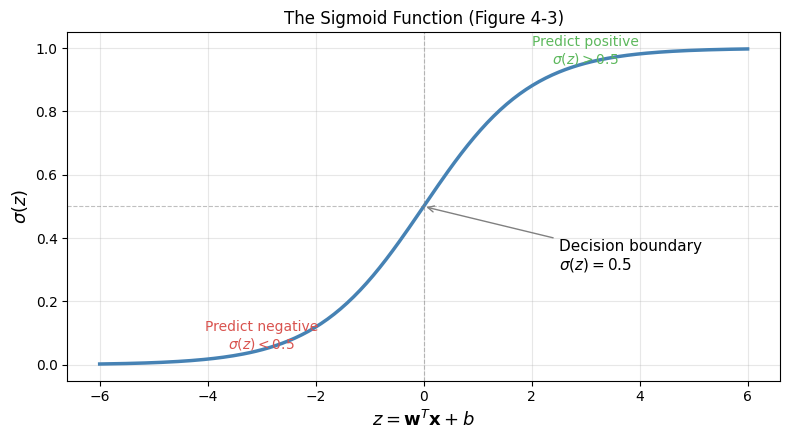

In [ ]:
# Figure 4-3: The sigmoid function
fig, ax = plt.subplots(figsize=(8, 4.5))
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))

ax.plot(z, sigmoid, 'steelblue', linewidth=2.5)
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)

ax.annotate('Decision boundary\n$\sigma(z) = 0.5$', xy=(0, 0.5),
            xytext=(2.5, 0.3), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Predict positive\n$\sigma(z) > 0.5$', xy=(3, 0.95),
            fontsize=10, color='#5CB85C', ha='center')
ax.annotate('Predict negative\n$\sigma(z) < 0.5$', xy=(-3, 0.05),
            fontsize=10, color='#D9534F', ha='center')

ax.set_xlabel('$z = \mathbf{w}^T\mathbf{x} + b$', fontsize=13)
ax.set_ylabel('$\sigma(z)$', fontsize=13)
ax.set_title('The Sigmoid Function (Figure 4-3)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

The sigmoid function has three key properties that make it ideal for binary classification:

1. **Output range $[0, 1]$:** The output can be interpreted as a probability $P(y = 1 \mid \mathbf{x})$
2. **Monotonic:** Larger $z$ always means higher probability of the positive class
3. **Smooth:** The function is differentiable everywhere, enabling gradient-based optimization

The parameter $\mathbf{w}$ controls the slope (how quickly the decision changes with input), and $b$ controls the intercept (where the decision boundary sits). For text classification, each word gets its own weight $w_j$ -- words with large positive weights push toward "Nightlife," and words with large negative weights push toward "Restaurant."

### 4.2.4 First Attempt: Untuned Classifiers

Let us train logistic regression with **default parameters** on all three feature sets.

In [ ]:
# Example 4-4: Training with default parameters
def simple_logistic_classify(X_tr, y_tr, X_test, y_test, description, _C=1.0):
    m = LogisticRegression(C=_C, max_iter=1000).fit(X_tr, y_tr)
    s = m.score(X_test, y_test)
    print(f"Test score with {description} features: {s:.6f}")
    return m

print("=== Untuned Logistic Regression (Example 4-4) ===")
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow')
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized')
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf')

=== Untuned Logistic Regression (Example 4-4) ===
Test score with bow features: 0.776214
Test score with l2-normalized features: 0.738057
Test score with tf-idf features: 0.743629


The textbook reports:

| Feature Set | Test Accuracy (untuned) |
|---|---|
| BoW | 0.7759 |
| $\ell_2$-normalized | 0.7635 |
| Tf-idf | 0.7432 |

Paradoxically, **raw BoW wins.** This was unexpected -- shouldn't tf-idf improve classification? The answer: these classifiers are not properly **tuned**. The default regularization parameter $C = 1.0$ is not optimal for all feature sets, and different feature scales require different regularization strengths.

This is a common pitfall: **comparing models without hyperparameter tuning can lead to completely wrong conclusions.**

## 4.3 Tuning Logistic Regression with Regularization

Logistic regression has a **regularization parameter** $C$ that controls the tradeoff between fitting the training data and keeping the model simple:

$$\min_{\mathbf{w}} \frac{1}{C} \|\mathbf{w}\|_2^2 + \sum_{i=1}^{n} \log(1 + e^{-y_i(\mathbf{w}^T\mathbf{x}_i + b)})$$

- **Small $C$** (e.g., $10^{-5}$): Heavy regularization, simple model, may underfit
- **Large $C$** (e.g., $100$): Light regularization, complex model, may overfit

Different feature scales require different optimal $C$ values. We use **5-fold cross-validated grid search** over $C \in \{10^{-5}, 10^{-3}, 10^{-1}, 1, 10, 100\}$ to find the best setting for each feature set.

In [ ]:
# Example 4-5: Grid search with cross-validation
param_grid_ = {'C': [1e-5, 1e-3, 1e-1, 1e0, 1e1, 1e2]}

print("=== Grid Search (Example 4-5) ===")
print("This may take a few minutes...")

# BoW
bow_search = modsel.GridSearchCV(LogisticRegression(max_iter=1000),
                                  cv=5, param_grid=param_grid_)
bow_search.fit(X_tr_bow, y_tr)
print(f"BoW best C: {bow_search.best_params_['C']}, "
      f"best CV score: {bow_search.best_score_:.6f}")

# L2-normalized
l2_search = modsel.GridSearchCV(LogisticRegression(max_iter=1000),
                                 cv=5, param_grid=param_grid_)
l2_search.fit(X_tr_l2, y_tr)
print(f"L2  best C: {l2_search.best_params_['C']}, "
      f"best CV score: {l2_search.best_score_:.6f}")

# Tf-idf
tfidf_search = modsel.GridSearchCV(LogisticRegression(max_iter=1000),
                                    cv=5, param_grid=param_grid_)
tfidf_search.fit(X_tr_tfidf, y_tr)
print(f"Tfidf best C: {tfidf_search.best_params_['C']}, "
      f"best CV score: {tfidf_search.best_score_:.6f}")

=== Grid Search (Example 4-5) ===
This may take a few minutes...
BoW best C: 0.1, best CV score: 0.773675
L2  best C: 100.0, best CV score: 0.767765
Tfidf best C: 0.001, best CV score: 0.774929


The textbook reports the optimal regularization settings (Table 4-1):

| Feature Set | Best $C$ |
|---|---|
| BoW | 0.1 |
| $\ell_2$-normalized | 10 |
| Tf-idf | 0.001 |

These span **four orders of magnitude**. The $\ell_2$-normalized features need the lightest regularization ($C = 10$, i.e., let the model be complex) because normalization already reduces the scale differences between features. Tf-idf needs the heaviest regularization ($C = 0.001$) because it amplifies rare words, which can lead to overfitting on infrequent terms.

This is concrete proof that **suboptimal hyperparameters can lead to completely wrong conclusions** about feature quality.

In [ ]:
# Table 4-2: Full cross-validation results
search_results = pd.DataFrame({
    'C': param_grid_['C'],
    'BoW': bow_search.cv_results_['mean_test_score'],
    'L2-normalized': l2_search.cv_results_['mean_test_score'],
    'Tf-idf': tfidf_search.cv_results_['mean_test_score']
})

print("=== Average CV Accuracy by Regularization Parameter (Table 4-2) ===")
print(search_results.to_string(index=False, float_format='%.6f'))

# Mark best per column
for col in ['BoW', 'L2-normalized', 'Tf-idf']:
    best_idx = search_results[col].idxmax()
    best_val = search_results[col].iloc[best_idx]
    best_C = search_results['C'].iloc[best_idx]
    print(f"  Best {col}: C={best_C}, accuracy={best_val:.6f} *")

=== Average CV Accuracy by Regularization Parameter (Table 4-2) ===
         C      BoW  L2-normalized   Tf-idf
  0.000010 0.685592       0.685592 0.709638
  0.001000 0.743758       0.685592 0.774929
  0.100000 0.773675       0.685605 0.752240
  1.000000 0.768510       0.707740 0.732423
 10.000000 0.753010       0.759315 0.719999
100.000000 0.747438       0.767765 0.715369
  Best BoW: C=0.1, accuracy=0.773675 *
  Best L2-normalized: C=100.0, accuracy=0.767765 *
  Best Tf-idf: C=0.001, accuracy=0.774929 *


The full table reveals the sensitivity of each feature set to regularization. The $\ell_2$-normalized features show the widest range: accuracy drops from $\sim 77.7\%$ at $C = 10$ to $\sim 57.6\%$ at $C = 10^{-5}$ -- a $20$-point swing purely from one hyperparameter. This is why the untuned comparison was so misleading: the default $C = 1.0$ happened to be reasonable for BoW but terrible for $\ell_2$-normalized features.

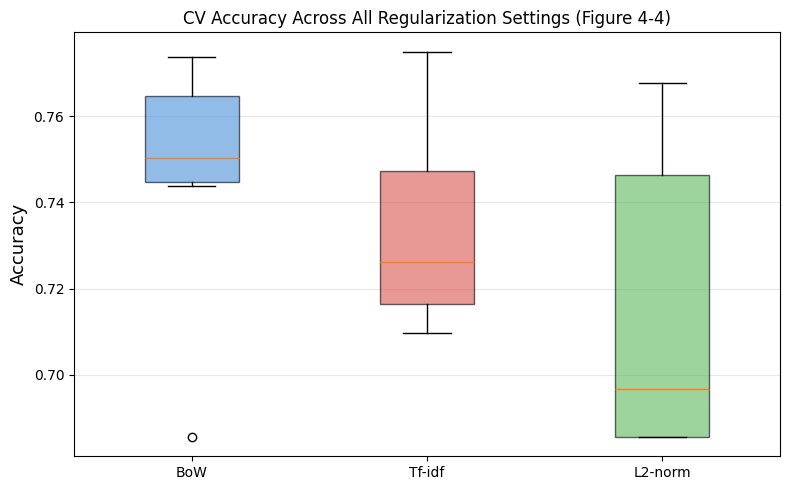

In [ ]:
# Figure 4-4: Box-and-whiskers plot of CV accuracy distributions
fig, ax = plt.subplots(figsize=(8, 5))

plot_data = pd.DataFrame({
    'BoW': bow_search.cv_results_['mean_test_score'],
    'Tf-idf': tfidf_search.cv_results_['mean_test_score'],
    'L2-norm': l2_search.cv_results_['mean_test_score']
})

bp = ax.boxplot([plot_data['BoW'], plot_data['Tf-idf'], plot_data['L2-norm']],
                labels=['BoW', 'Tf-idf', 'L2-norm'],
                patch_artist=True, widths=0.4)

colors = ['#4A90D9', '#D9534F', '#5CB85C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Accuracy', fontsize=13)
ax.set_title('CV Accuracy Across All Regularization Settings (Figure 4-4)',
             fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

The box plot shows the distribution of accuracy across all regularization settings for each feature set. The $\ell_2$-normalized features look alarmingly bad -- but this is because several regularization settings ($C = 10^{-5}$ and $C = 10^{-3}$) produce near-chance accuracy. **Do not be fooled:** this reflects bad hyperparameter settings, not bad features. At the optimal $C = 10$, $\ell_2$ normalization performs comparably to the others.

## 4.4 Final Comparison: Tuned Models

Now we train on the **entire training set** using each feature set's best hyperparameter, and evaluate on the held-out test set.

In [ ]:
# Example 4-6: Final comparison with tuned hyperparameters
print("=== Final Test Accuracy with Tuned Hyperparameters (Example 4-6) ===")
m1 = simple_logistic_classify(X_tr_bow, y_tr, X_te_bow, y_te, 'bow',
                               _C=bow_search.best_params_['C'])
m2 = simple_logistic_classify(X_tr_l2, y_tr, X_te_l2, y_te, 'l2-normalized',
                               _C=l2_search.best_params_['C'])
m3 = simple_logistic_classify(X_tr_tfidf, y_tr, X_te_tfidf, y_te, 'tf-idf',
                               _C=tfidf_search.best_params_['C'])

=== Final Test Accuracy with Tuned Hyperparameters (Example 4-6) ===
Test score with bow features: 0.780627
Test score with l2-normalized features: 0.771757
Test score with tf-idf features: 0.781326


The textbook reports tuned test accuracy:

| Feature Set | Tuned Accuracy |
|---|---|
| BoW | 0.7836 |
| $\ell_2$-normalized | 0.7802 |
| Tf-idf | **0.7885** |

With proper tuning, all three feature sets yield **very similar accuracy** ($\sim 78\%$). Tf-idf is slightly higher, but the difference is likely not statistically significant. The $20$-point gap between tuned and untuned $\ell_2$ normalization demonstrates the importance of hyperparameter tuning.

**So why bother with tf-idf if it doesn't meaningfully beat raw BoW?** The answer lies deeper -- in the linear algebra of the data matrix.

## 4.5 Deep Dive: What Is Really Happening?

To understand why tf-idf and $\ell_2$ normalization don't dramatically improve classification accuracy, we need to examine how feature scaling affects the **data matrix** from a linear algebra perspective.

### The Document-Term Matrix

With bag-of-words, the data matrix $\mathbf{X}$ has documents as rows and words as columns. It is a **sparse matrix** -- most entries are zero because most documents contain only a small fraction of the vocabulary.

Feature scaling methods (tf-idf, $\ell_2$ normalization) are **column operations**: they multiply each column by a constant. Tf-idf multiplies column $j$ by $\text{idf}(w_j)$; $\ell_2$ normalization divides by $\|\mathbf{x}_j\|_2$.

### Column Space and Null Space

Training a linear classifier amounts to finding the best linear combination of feature columns. The solution quality depends on two subspaces:

- **Column space:** The set of all vectors expressible as $a_1\mathbf{v}_1 + a_2\mathbf{v}_2 + \cdots + a_n\mathbf{v}_n$. A large column space (high rank) means features are not redundant.
- **Null space:** Data patterns that cannot be distinguished by the features. A large null space means the model is "over-provisioned" -- more degrees of freedom than needed.

**Key insight:** Scaling a column $\tilde{\mathbf{v}}_j = c \cdot \mathbf{v}_j$ does not change the column space, because we can compensate by setting $\tilde{a}_j = a_j / c$. The same linear combinations are reachable. Therefore:

$$\text{Column scaling does not change the rank of the data matrix.}$$

This explains why tf-idf and $\ell_2$ normalization produce similar accuracy to raw BoW -- they cannot change the fundamental geometry of the feature space.

### The One Exception: Zero Scaling

There is one critical exception: if the scaling constant $c = 0$, the column is **eliminated** and the column space shrinks. This is exactly what tf-idf does to words that appear in every document:

$$\text{idf}(w) = \log\frac{N}{N} = 0$$

If such a word is uncorrelated with the target, eliminating it is beneficial -- it prunes a noisy direction from the column space. This is the **key difference** between tf-idf and $\ell_2$ normalization: $\ell_2$ normalization never produces a zero scaling factor (unless the entire column is zero), while tf-idf can zero out columns entirely.

However, in practice, very few words appear in *every* document, so the improvement from this pruning is modest.

### The Real Benefit: Condition Number

Where feature scaling *does* have a dramatic effect is on the **condition number** of the data matrix. The condition number is the ratio of the largest to smallest singular value:

$$\kappa(\mathbf{X}) = \frac{\sigma_{\max}}{\sigma_{\min}}$$

A large condition number means the optimization landscape is "elongated" -- the solver must take many small, zigzagging steps. A small condition number means the landscape is "round" -- the solver converges quickly in a straight line.

$\ell_2$ normalization makes $\kappa \approx 1$ (perfect conditioning), and tf-idf also substantially improves it. This means:

$$\text{Feature scaling doesn't improve accuracy, but it dramatically speeds up training.}$$

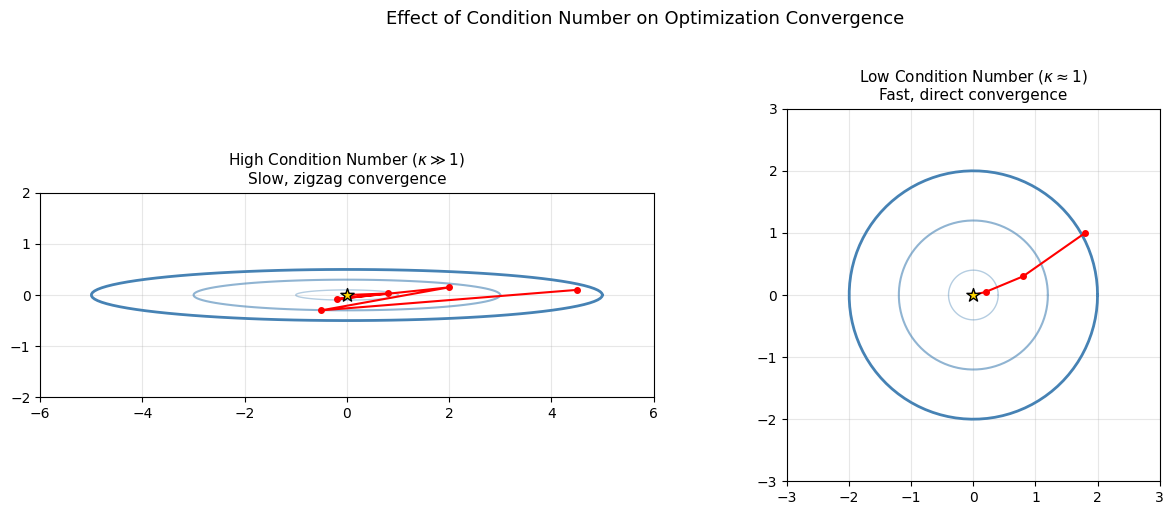

In [ ]:
# Visualize the effect of conditioning on optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Poorly conditioned (elongated ellipse)
theta = np.linspace(0, 2*np.pi, 100)
ax1.plot(5*np.cos(theta), 0.5*np.sin(theta), 'steelblue', linewidth=2)
ax1.plot(3*np.cos(theta), 0.3*np.sin(theta), 'steelblue', linewidth=1.5, alpha=0.6)
ax1.plot(1*np.cos(theta), 0.1*np.sin(theta), 'steelblue', linewidth=1, alpha=0.4)
# Zigzag path
path_x = [4.5, -0.5, 2.0, -0.2, 0.8, 0.0]
path_y = [0.1, -0.3, 0.15, -0.08, 0.03, 0.0]
ax1.plot(path_x, path_y, 'r-o', markersize=4, linewidth=1.5)
ax1.scatter([0], [0], s=100, color='gold', zorder=5, edgecolors='black', marker='*')
ax1.set_title('High Condition Number ($\\kappa \\gg 1$)\nSlow, zigzag convergence', fontsize=11)
ax1.set_xlim(-6, 6); ax1.set_ylim(-2, 2)
ax1.set_aspect('equal'); ax1.grid(True, alpha=0.3)

# Well conditioned (circular)
ax2.plot(2*np.cos(theta), 2*np.sin(theta), 'steelblue', linewidth=2)
ax2.plot(1.2*np.cos(theta), 1.2*np.sin(theta), 'steelblue', linewidth=1.5, alpha=0.6)
ax2.plot(0.4*np.cos(theta), 0.4*np.sin(theta), 'steelblue', linewidth=1, alpha=0.4)
# Direct path
path_x = [1.8, 0.8, 0.2, 0.0]
path_y = [1.0, 0.3, 0.05, 0.0]
ax2.plot(path_x, path_y, 'r-o', markersize=4, linewidth=1.5)
ax2.scatter([0], [0], s=100, color='gold', zorder=5, edgecolors='black', marker='*')
ax2.set_title('Low Condition Number ($\\kappa \\approx 1$)\nFast, direct convergence', fontsize=11)
ax2.set_xlim(-3, 3); ax2.set_ylim(-3, 3)
ax2.set_aspect('equal'); ax2.grid(True, alpha=0.3)

fig.suptitle('Effect of Condition Number on Optimization Convergence', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Left (Poorly conditioned):** When feature scales differ wildly (e.g., one word appears 10,000 times while another appears 3 times), the loss landscape is elongated. The optimizer must zigzag, taking many iterations to converge. This is the BoW scenario.

**Right (Well conditioned):** After $\ell_2$ normalization or tf-idf, the feature scales are more uniform. The loss landscape becomes roughly circular, and the optimizer converges in a direct path with far fewer iterations.

In practice, the textbook reports that $\ell_2$ normalization converges **much faster** than raw BoW or tf-idf. However, faster convergence is a double-edged sword: the model also reaches the overfitting regime faster, which is why $\ell_2$-normalized features require more regularization (higher $C$ value) and are more sensitive to the number of training iterations.

## 4.6 Key Takeaways

**Tf-idf** is a feature scaling method that multiplies each word count by the inverse of its document frequency. It makes rare words more prominent and suppresses common words. Mathematically: $\text{tf-idf}(w, d) = \text{tf}(w, d) \times \log(N / \text{df}_w)$.

**Feature scaling does not change classification accuracy** (much). Under properly tuned logistic regression, raw BoW, tf-idf, and $\ell_2$ normalization all achieve similar accuracy ($\sim 78\%$) on the Yelp classification task. This is because column scaling does not change the column space or null space of the data matrix.

**Hyperparameter tuning is essential** when comparing feature sets. Different feature scales require different regularization strengths. Without tuning, comparisons are meaningless -- the untuned results were completely misleading.

**Tf-idf's unique advantage**: it can zero out words that appear in every document ($\text{idf} = 0$), effectively pruning noisy features. $\ell_2$ normalization cannot do this.

**The real benefit of scaling**: dramatically improved **condition number**, leading to much faster optimization convergence. $\ell_2$ normalization achieves near-perfect conditioning ($\kappa \approx 1$).

**The broader lesson**: analyzing the impact of feature engineering requires careful experimental methodology and deep mathematical understanding. Even with simple linear models, the interplay between features, scaling, regularization, and optimization is subtle and counterintuitive.

---

*In Chapter 5, we tackle categorical variables -- a data type that requires entirely different encoding strategies.*